# Summary Statistics

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## GMI

In [2]:
METRICS = ["bias", "mae", "mse", "smape", "correlation_coef"]

In [3]:
import pandas as pd

def to_dataframe(
    results: xr.Dataset,
    algorithm: str
) -> pd.DataFrame:
    results = results.assign_coords(domain=["Austria", "CONUS", "Korea"])
    dframe = results[METRICS].to_dataframe()
    dframe["algorithm"] = algorithm
    dframe = (
        dframe.reset_index()
        .melt(
            id_vars=["algorithm", "domain"],
            value_vars=METRICS,
            var_name="metric",
            value_name="value",
        )
    )
    return dframe.sort_values(by=["domain"])


In [4]:
res_xgb = xr.load_dataset("../models/xgboost/test_results/xgboost_gmi_gmi_on_swath_m_tabular_n1000_d6_lr0100_sub080_col080_v0.nc")
res_xgb = to_dataframe(res_xgb, algorithm="XGBoost")

In [5]:
res_rf = xr.load_dataset("../models/random_forest/test_results/random_forest_gmi_gmi_on_swath_s_tabular_n100_dnull_split2_leaf1_featsqrt_v0.nc")
res_rf = to_dataframe(res_rf, algorithm="RandomForest")

In [7]:
res_bmci = xr.load_dataset("../models/bmci/test_results/bmci_gmi_gmi_on_swath_m_tabular_smean1600_c3000_v0.nc")
res_bmci = to_dataframe(res_bmci, algorithm="BMCI")

In [18]:
res_mlp = xr.load_dataset("../models/fully_connected/test_results/data_scaling/fully_connected_gmi_gmi_on_swath_xl_tabular_256x256x256x256_nodrop_adamw_warmup_cosine_annealing_restarts_v01.nc")
res_mlp = to_dataframe(res_mlp, algorithm="MLP")

In [19]:
res_unet = xr.load_dataset("../models/basic_unet/test_results/unet_gmi_gmi_gridded_xl_adamw_reduce_on_plateau_v03.nc")
res_unet = to_dataframe(res_unet, algorithm="U-Net")

In [20]:
res_unetx = xr.load_dataset("../models/basic_unet/test_results/unet_gmi_gmi_gridded_xl_sgd_cosine_annealing_restarts_v03.nc")
res_unetx = to_dataframe(res_unetx, algorithm="U-Net*")

In [21]:
res_unetxx = xr.load_dataset("../models/encoder_decoder/test_results/encoder_decoder_gmi_gmi_gridded_xl_resnext_in13_ch64x128x256x512_d2_out1_bilinear_adamw_cosine_annealing_restarts_v00.nc")
res_unetxx = to_dataframe(res_unetxx, algorithm="U-Net**")

In [22]:
from satrain.baselines import get_ranked_results
res_baseline = get_ranked_results("gmi", METRICS, ["gprof_v07", "gprof_ir"])

res_all = pd.concat((
    res_baseline,
    res_rf,
    res_xgb,
    res_bmci,
    res_mlp,
    res_unet,
    res_unetx,
    res_unetxx
)).reset_index()

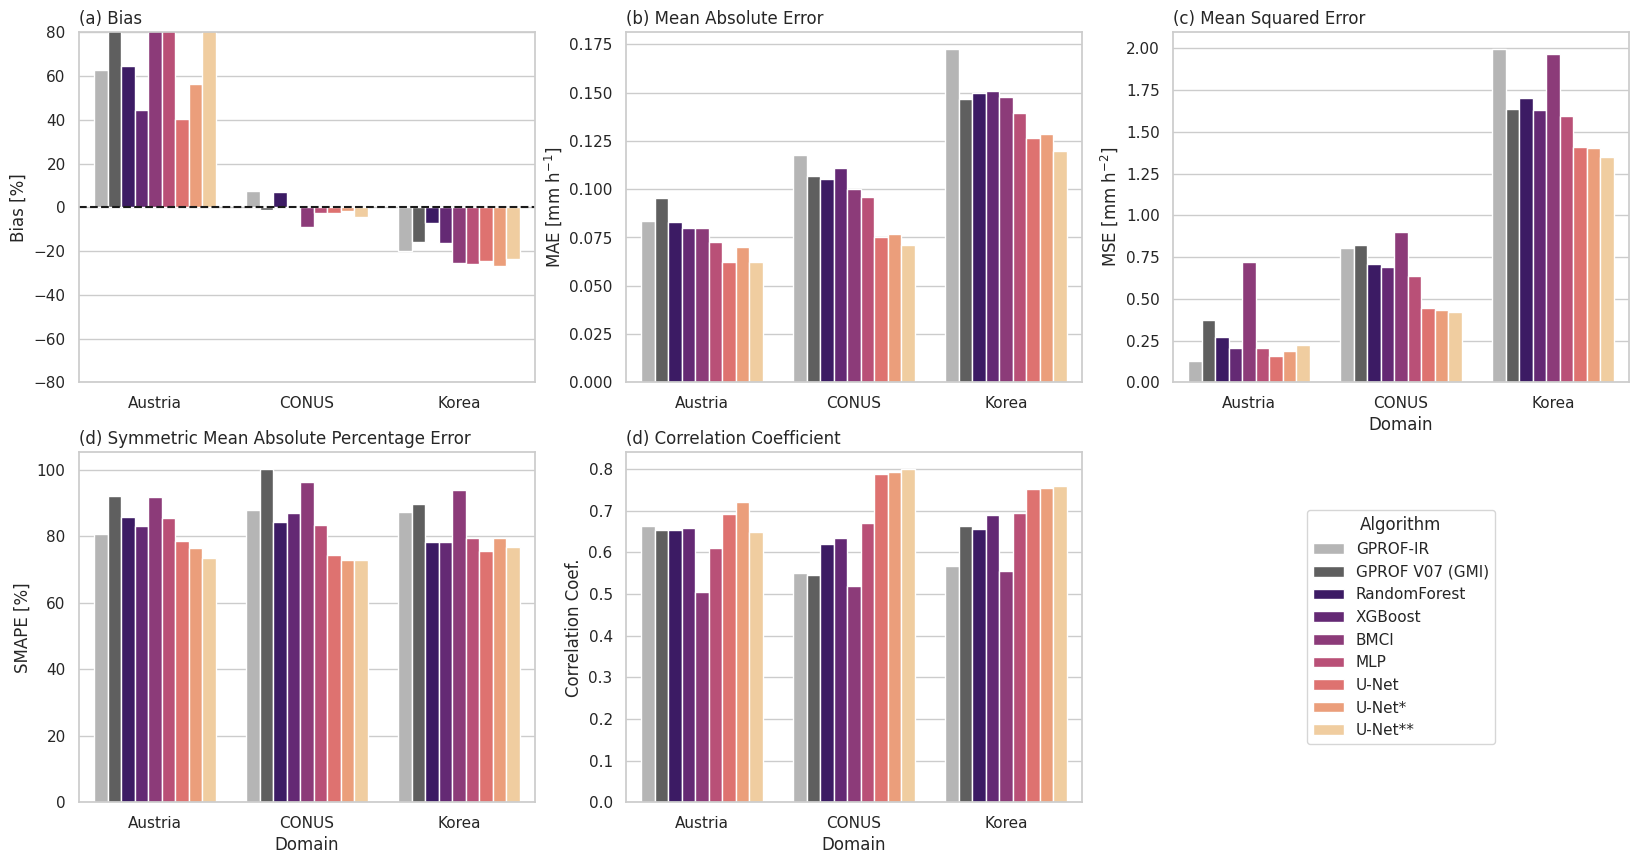

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 3)

cmap = plt.get_cmap("Greys")
palette_baselines = [cmap(val) for val in np.linspace(0.4, 0.7, 2)]
#cmap = plt.get_cmap("Purples")
#palette_pixel = [cmap(val) for val in np.linspace(0.3, 0.9, 4)]
#cmap = plt.get_cmap("Oranges")
#palette_cnn = [cmap(val) for val in np.linspace(0.2, 0.8, 3)]
cmap = plt.get_cmap("magma")
palette_all = [cmap(val) for val in np.linspace(0.2, 0.9, 7)]
#cmap = plt.get_cmap("Oranges")
#palette_cnn = [cmap(val) for val in np.linspace(0.2, 0.8, 3)]
#palette = palette_baselines + palette_pixel + palette_cnn
palette = palette_baselines + palette_all

# Bias
ax = fig.add_subplot(gs[0, 0])
sns.barplot(
    data=res_all.loc[res_all.metric == "bias"],
    x="domain",
    y="value",
    hue="algorithm",
    palette=palette
)
handles, labels = ax.get_legend_handles_labels()
ax.legend().remove()
ax.set_ylabel("Bias [%]")
ax.axhline(y=0, ls="--", c="k")
ax.set_ylim(-80, 80)
ax.set_title("(a) Bias", loc="left")
ax.set_xlabel(None)

# MAE
ax = fig.add_subplot(gs[0, 1])
sns.barplot(
    data=res_all.loc[res_all.metric == "mae"],
    x="domain",
    y="value",
    hue="algorithm",
    palette=palette,
    legend=False
)
ax.set_ylabel("MAE [mm h$^{-1}$]")
ax.set_title("(b) Mean Absolute Error", loc="left")
ax.set_xlabel(None)

# MSE
ax = fig.add_subplot(gs[0, 2])
sns.barplot(
    data=res_all.loc[res_all.metric == "mse"],
    x="domain",
    y="value",
    hue="algorithm",
    palette=palette,
    legend=False
)
ax.set_xlabel("Domain")
ax.set_ylabel("MSE [mm h$^{-2}$]")
ax.set_title("(c) Mean Squared Error", loc="left")

# SMAPE
ax = fig.add_subplot(gs[1, 0])
sns.barplot(
    data=res_all.loc[res_all.metric == "smape"],
    x="domain",
    y="value",
    hue="algorithm",
    palette=palette,
    legend=False
)
ax.set_xlabel("Domain")
ax.set_ylabel("SMAPE [%]")
ax.set_title("(d) Symmetric Mean Absolute Percentage Error", loc="left")

# Correlation Coef.
ax = fig.add_subplot(gs[1, 1])
sns.barplot(
    data=res_all.loc[res_all.metric == "correlation_coef"],
    x="domain",
    y="value",
    hue="algorithm",
    palette=palette,
    legend=False
)
ax.set_xlabel("Domain")
ax.set_ylabel("Correlation Coef.")
ax.set_title("(d) Correlation Coefficient", loc="left")

lax = fig.add_subplot(gs[1, 2])
lax.set_axis_off()
lax.legend(handles=handles, loc="center", title="Algorithm")
